<a href="https://colab.research.google.com/github/satya1-5/projects/blob/master/house_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np

# Read the uploaded CSV file
df = pd.read_csv("/content/House Price Prediction Dataset.csv")

# Display dataset
print(df.head())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  


In [16]:
# Number of rows and columns
print(df.shape)

# Column names
print(df.columns)

# Dataset information
print(df.info())

# Check missing values
#print(df.isnull().sum())

(2000, 10)
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
None


In [17]:
df.describe()


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": "#f0f8ff",    # light pastel blue
        "figure.facecolor": "#f0f8ff",
        "axes.edgecolor": "#0a3d62",
        "axes.labelcolor": "#0a3d62",
        "xtick.color": "#0a3d62",
        "ytick.color": "#0a3d62",
        "text.color": "#0a3d62",
        "grid.color": "#d6eaf8"
    }
)

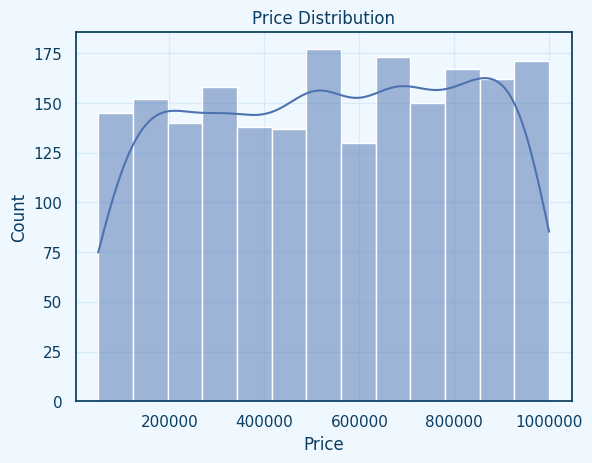

In [19]:
sns.histplot(df['Price'],kde=True)
plt.gca().ticklabel_format(style='plain')
plt.title('Price Distribution')
plt.show()

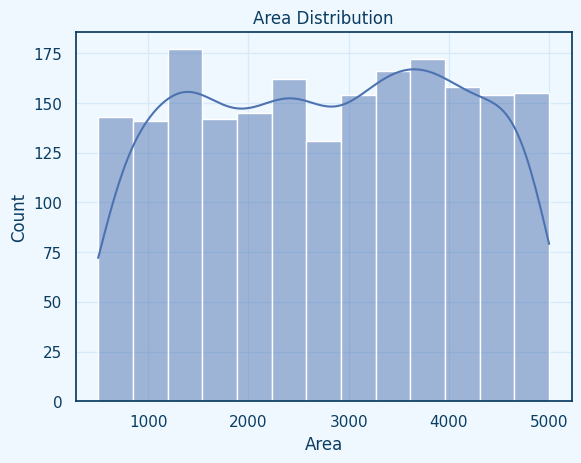

In [20]:
sns.histplot(df['Area'],kde=True)
plt.gca().ticklabel_format(style='plain')
plt.title('Area Distribution')
plt.show()

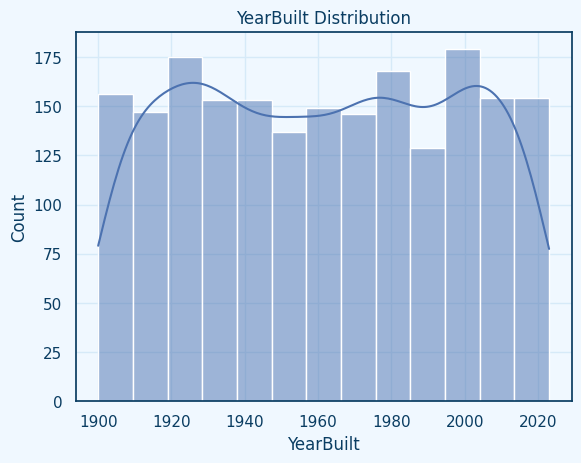

In [21]:
sns.histplot(df['YearBuilt'],kde=True)
plt.title('YearBuilt Distribution')
plt.show()


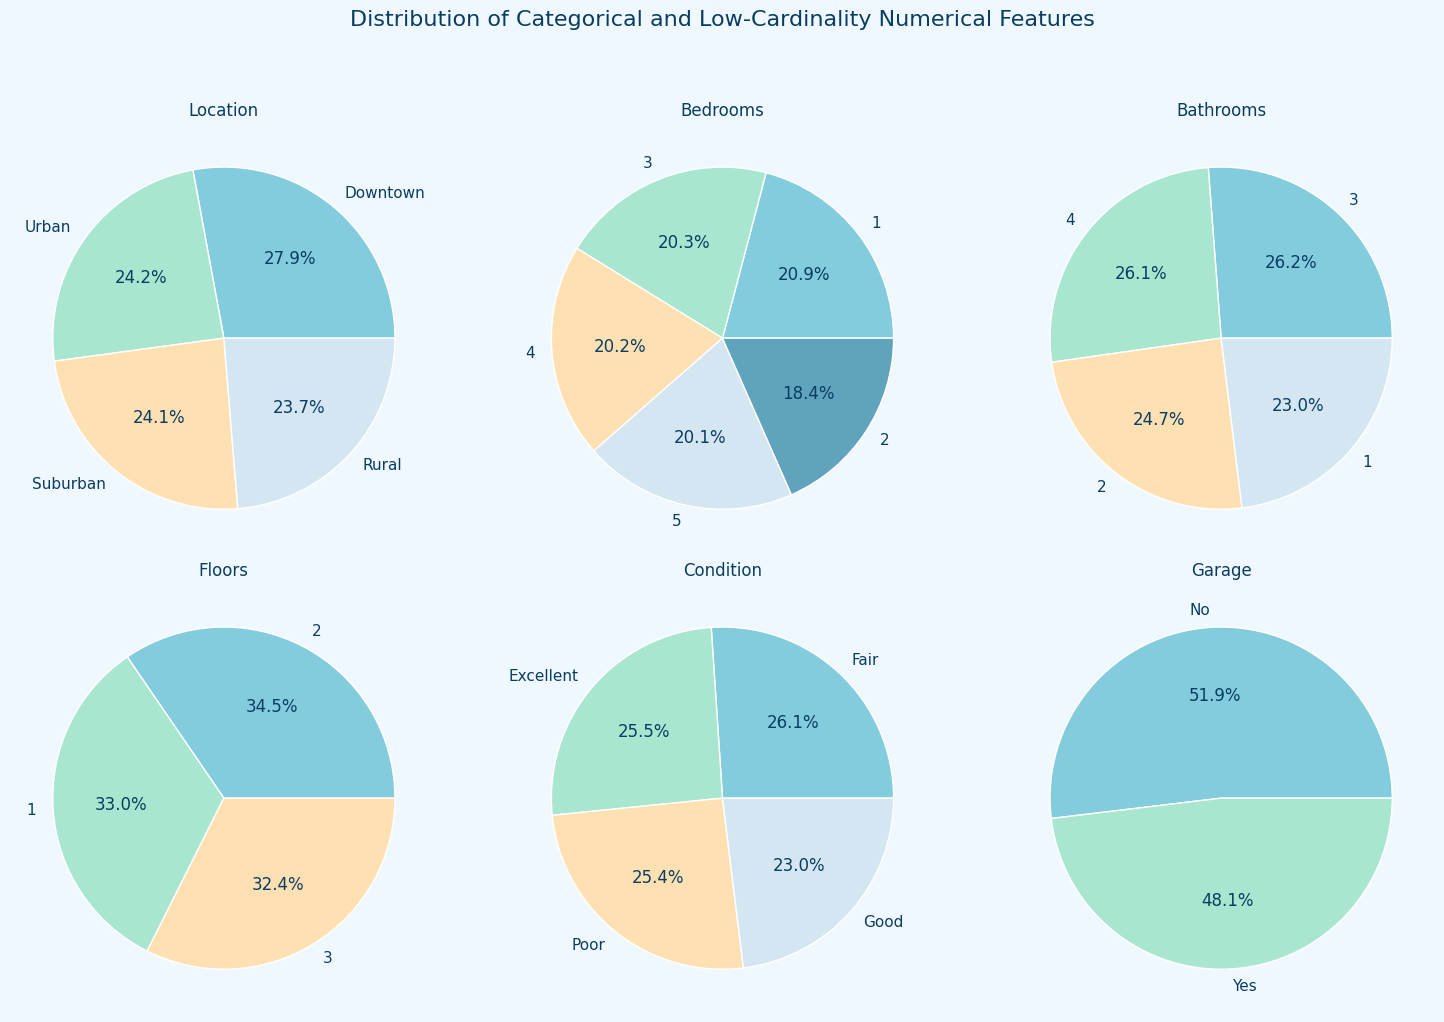

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select columns suitable for pie charts (categorical or low-cardinality numerical)
cols_for_pie_charts = ['Location', 'Bedrooms', 'Bathrooms', 'Floors', 'Condition', 'Garage']
pie_colors = ["#82ccdd", "#a8e6cf", "#ffe0b2", "#d4e6f1", "#60a3bc", "#a1c9f4"]

# Create a figure to hold all subplots
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_for_pie_charts):
  # Create a 2x3 grid of subplots. 'i + 1' ensures the subplot index is 1-based
  plt.subplot(2, 3, i + 1)
  plt.pie(df[col].value_counts(), labels=df[col].value_counts().index, autopct='%1.1f%%', colors=pie_colors)
  plt.title(col)

plt.suptitle('Distribution of Categorical and Low-Cardinality Numerical Features', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle from overlapping
plt.show()

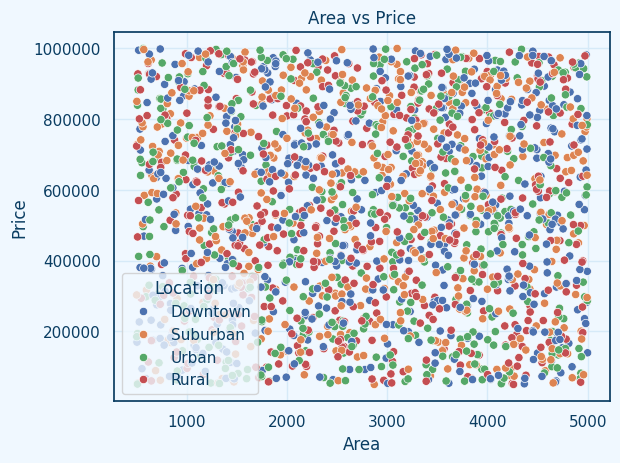

In [23]:
sns.scatterplot(x=df['Area'],y=df['Price'],hue=df['Location'])
plt.gca().ticklabel_format(style='plain')
plt.title('Area vs Price')
plt.show()

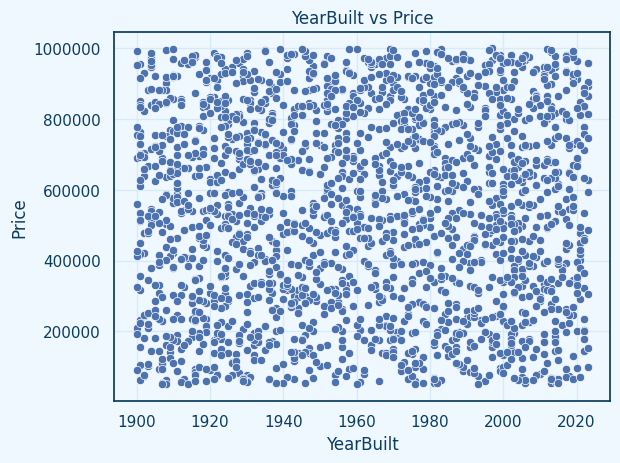

In [24]:
sns.scatterplot(x=df['YearBuilt'],y=df['Price'])
plt.gca().ticklabel_format(style='plain')
plt.title('YearBuilt vs Price')
plt.show()


/tmp/ipykernel_2295/1207854878.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Condition'],y=df['Price'], palette=palette_bars)
/tmp/ipykernel_2295/1207854878.py:3: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.boxplot(x=df['Condition'],y=df['Price'], palette=palette_bars)


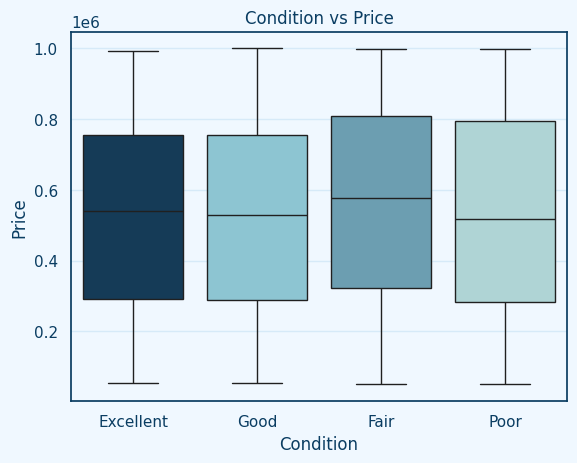

In [25]:
palette_bars = ["#0a3d62", "#82ccdd", "#60a3bc", "#a8dadc", "#d4e6f1"]

sns.boxplot(x=df['Condition'],y=df['Price'], palette=palette_bars)
plt.title('Condition vs Price')
plt.show()

/tmp/ipykernel_2295/3153362616.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Bedrooms'],y=df['Price'], palette=palette_bars)


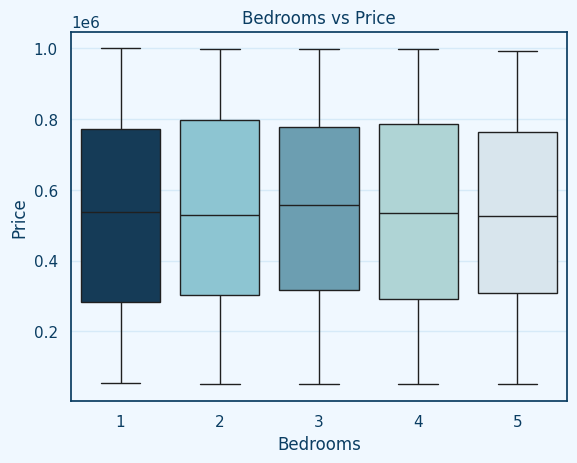

In [26]:
sns.boxplot(x=df['Bedrooms'],y=df['Price'], palette=palette_bars)
plt.title('Bedrooms vs Price')
plt.show()


/tmp/ipykernel_2295/2129299630.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Location'],y=df['Price'], palette=palette_bars)
/tmp/ipykernel_2295/2129299630.py:1: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.boxplot(x=df['Location'],y=df['Price'], palette=palette_bars)


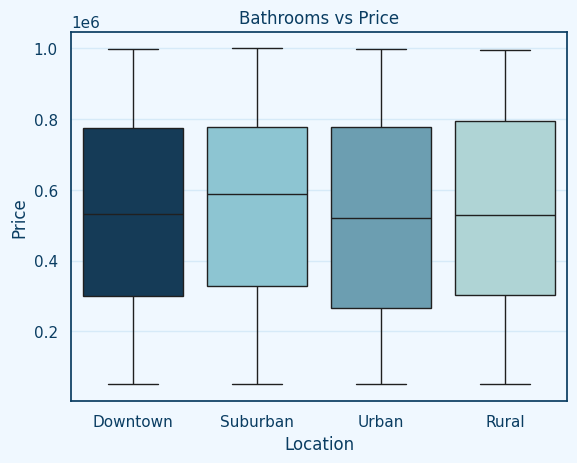

In [27]:
sns.boxplot(x=df['Location'],y=df['Price'], palette=palette_bars)
plt.title('Bathrooms vs Price')
plt.show()


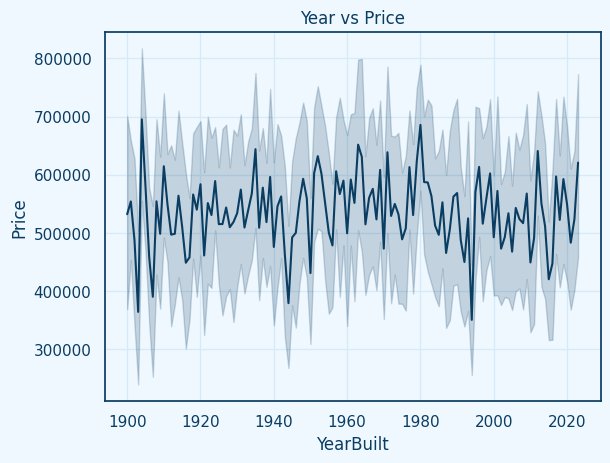

In [28]:
line_colors = ["#0a3d62", "#126e82", "#51a8b1", "#82ccdd"]

sns.lineplot(x=df['YearBuilt'],y=df['Price'],color=line_colors[0])
plt.title('Year vs Price')
plt.show()

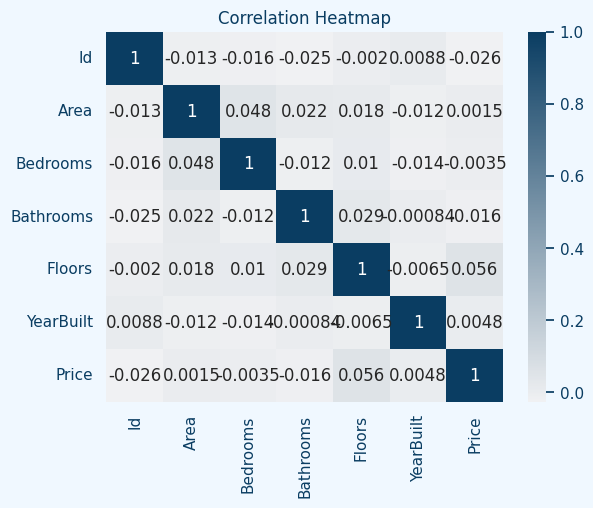

In [29]:
heatmap_cmap = sns.light_palette("#0a3d62", as_cmap=True)

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap=heatmap_cmap)
plt.title('Correlation Heatmap')
plt.show()

In [30]:
df.drop(columns=['Id'],inplace=True)
location_rank = {
    'Rural': 0,
    'Suburban': 1,
    'Urban': 2,
    'Downtown': 3
}
df['Location'] = df['Location'].map(location_rank)

condition = {
    'Poor': 0,
    'Fair': 1,
    'Good': 3,
    'Excellent': 4
}
df['Condition'] = df['Condition'].map(condition)

df['Garage'] = df['Garage'].map({'Yes': 1, 'No': 0})

df['Age'] = 2023 - df['YearBuilt']
df.drop(columns=['YearBuilt'],inplace=True)

In [31]:
# Drop 'Id' column if it exists
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)
else:
    print("Warning: 'Id' column not found. Skipping drop.")

location_rank = {
    'Rural': 0,
    'Suburban': 1,
    'Urban': 2,
    'Downtown': 3
}

# Map 'Location' if it exists and is an object (string) type
if 'Location' in df.columns and df['Location'].dtype == 'object':
    df['Location'] = df['Location'].map(location_rank)
else:
    print("Warning: 'Location' column not found or not of object type. Skipping mapping.")

condition_map = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Excellent': 3
}

# Map 'Condition' if it exists and is an object (string) type
if 'Condition' in df.columns and df['Condition'].dtype == 'object':
    df['Condition'] = df['Condition'].map(condition_map)
else:
    print("Warning: 'Condition' column not found or not of object type. Skipping mapping.")

# Map 'Garage' if it exists and is an object (string) type
if 'Garage' in df.columns and df['Garage'].dtype == 'object':
    df['Garage'] = df['Garage'].map({'Yes': 1, 'No': 0})
else:
    print("Warning: 'Garage' column not found or not of object type. Skipping mapping.")

# Create 'Age' and drop 'YearBuilt' if 'YearBuilt' exists
if 'YearBuilt' in df.columns:
    df['Age'] = 2023 - df['YearBuilt']
    df.drop(columns=['YearBuilt'], inplace=True)
else:
    print("Warning: 'YearBuilt' column not found. Skipping 'Age' creation and 'YearBuilt' drop.")

In [32]:
print(df.columns.tolist())

['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Location', 'Condition', 'Garage', 'Price', 'Age']


In [33]:
print(df.head())

   Area  Bedrooms  Bathrooms  Floors  Location  Condition  Garage   Price  Age
0  1360         5          4       3         3          4       0  149919   53
1  4272         5          4       3         3          4       0  424998   65
2  3592         2          2       3         3          3       0  266746   85
3   966         4          2       2         1          1       1  244020  121
4  4926         1          4       2         3          1       1  636056   48


In [34]:
import pandas as pd
import numpy as np

# Read the uploaded CSV file
df = pd.read_csv("/content/House Price Prediction Dataset.csv")

# Display dataset
print(df.head())


   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  


In [35]:
# Drop 'Id' column
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)
else:
    print("Warning: 'Id' column not found. Skipping drop.")

# Location mapping
location_rank = {
    'Rural': 0,
    'Suburban': 1,
    'Urban': 2,
    'Downtown': 3
}
# Strip whitespace before mapping
df['Location'] = df['Location'].astype(str).str.strip().map(location_rank)

# Condition mapping
condition = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Excellent': 3
}
# Strip whitespace before mapping
df['Condition'] = df['Condition'].astype(str).str.strip().map(condition)

# Garage mapping
# Strip whitespace before mapping
df['Garage'] = df['Garage'].astype(str).str.strip().map({
    'Yes': 1,
    'No': 0
})

# Create 'Age' and drop 'YearBuilt'
if 'YearBuilt' in df.columns:
    df['Age'] = 2023 - df['YearBuilt']
    df.drop(columns=['YearBuilt'], inplace=True)
else:
    print("Warning: 'YearBuilt' column not found. Skipping 'Age' creation and 'YearBuilt' drop.")

# Check any remaining missing values after all preprocessing
print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
Location     0
Condition    0
Garage       0
Price        0
Age          0
dtype: int64


In [36]:
from sklearn.preprocessing import StandardScaler
col = ['Area',]
scaler = StandardScaler()
df[col] = scaler.fit_transform(df[col])


In [37]:
X = df.drop(columns=['Price'],axis=1)
y = df['Price']

In [38]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [39]:
import numpy as np
from sklearn.impute import SimpleImputer

# Option A: Drop rows with NaN values
# df = df.dropna()

# Option B: Impute missing values with mean or median
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [40]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [41]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
print('R2 Score:',r2)
print('MAE:',mae)
print('MSE:',mse)


R2 Score: -0.013700478686581752
MAE: 244665.37118781477
MSE: 78864709711.87729


In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

In [44]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'Support Vector Machine': SVR(),
    'K-Nearest Neighbors': KNeighborsRegressor()
}

In [45]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f'{name}:')
    print(f'R2 Score: {r2}')

Linear Regression:
R2 Score: -0.013700478686581752
Random Forest:
R2 Score: -0.11477298188550611
Support Vector Machine:
R2 Score: -0.001332545501614435
K-Nearest Neighbors:
R2 Score: -0.2334046112890984


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

# --- Data Loading and Preprocessing (copied from previous cells to ensure X_train and y_train are defined) ---
# Read the uploaded CSV file
df = pd.read_csv("/content/House Price Prediction Dataset.csv")

# Drop 'Id' column
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)

# Location mapping
location_rank = {
    'Rural': 0,
    'Suburban': 1,
    'Urban': 2,
    'Downtown': 3
}
df['Location'] = df['Location'].astype(str).str.strip().map(location_rank)

# Condition mapping
condition = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Excellent': 3
}
df['Condition'] = df['Condition'].astype(str).str.strip().map(condition)

# Garage mapping
df['Garage'] = df['Garage'].astype(str).str.strip().map({'Yes': 1, 'No': 0})

# Create 'Age' and drop 'YearBuilt'
if 'YearBuilt' in df.columns:
    df['Age'] = 2023 - df['YearBuilt']
    df.drop(columns=['YearBuilt'], inplace=True)

# Scale 'Area' column
col_to_scale = ['Area']
scaler = StandardScaler()
df[col_to_scale] = scaler.fit_transform(df[col_to_scale])

# Define X and y
X = df.drop(columns=['Price'], axis=1)
y = df['Price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Impute missing values (if any, though previous steps should ensure none)
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
# --- End of Data Preparation ---


svr = SVR()

# Define a simplified hyperparameter grid for faster execution
param_grid = {
    'kernel': ['linear', 'rbf'], # Reduced kernel options
    'C': [1, 10], # Reduced C options
    'epsilon': [0.1, 0.2], # Reduced epsilon options
    'gamma': ['scale', 'auto']  # only used for 'rbf'
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # can also use 'r2'
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Predict using the best model
best_svr = grid_search.best_estimator_
y_pred = best_svr.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mse)
print("RMSE:", rmse)
print("R^2:", R2)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'C': 1, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
RMSE: 279110.19210673304
R^2: -0.0013325498587877238
